# PopOut — Decision Tree AI Pipeline

This notebook trains and evaluates ID3 decision-tree agents for the PopOut board game.
It is **model-agnostic**: switch `ACTIVE_MODEL` in the toggle cell (cell 2) to run the
full pipeline on any of the four dataset versions without changing anything else.

## How the toggle works

```python
ACTIVE_MODEL = 'v1'   # ← change to 'v1', 'v2', 'v3', or 'v4'
```

Each version has its own entry in `MODEL_CONFIGS` controlling:

| Key | Meaning |
|---|---|
| `feat_depth` | Max depth for the ID3 tree trained on engineered features |
| `raw_depth` | Max depth for the raw-cells-only tree |
| `filter_can_win` | Whether to remove `can_win=1` positions before training (v4 only — wrapper handles them) |
| `raw_oversample` | Proven-position oversampling factor for the raw model (10× for small datasets, 4× for v4) |

Results are cached per version under `data/generated/{VERSION}/results/`.
Re-running a cell skips the expensive computation and loads from disk instead.

## Pipeline sections

1. **Dataset generation** — parallel self-play with MCTS-Solver records `(board state, best move)` pairs
2. **Data exploration** — class distribution and feature overview
3. **ID3 classifier** — train under three train/test splits, measure accuracy
4. **Feature sweep** — how accuracy scales with the number of top-IG features used
5. **Win-rate evaluation** — how often the tree beats MCTS in actual play, split by first- and second-player games
6. **Summary** — aggregate view across all versions: accuracy, overall win rate, and P1 vs P2 advantage
---

**Inteligência Artificial 2025/2026 — Trabalho Prático**

**Grupo**:
- [ALUNO 1: Nome Completo, Número Mecanográfico]
- [ALUNO 2: Nome Completo, Número Mecanográfico]
- [ALUNO 3: Nome Completo, Número Mecanográfico]

**Repositório**: <https://github.com/Difl4/popout-ai>


In [52]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 20


In [ ]:
import json as _json

# ── Model toggle ──────────────────────────────────────────────────────────────
# Change ACTIVE_MODEL to switch datasets. Pre-saved results are loaded
# automatically so expensive sections are skipped on subsequent runs.
# Available keys: 'v1', 'v2', 'v3', 'v4'
AVAILABLE_MODELS = {
    'v1': 'v1_3000games_100k',
    'v2': 'v2_5000games_100k',
    'v3': 'v3_5000games_tiered',
    'v4': 'v4_75k_100k',
}

# Depths match the trained .pkl files for each version
MODEL_CONFIGS = {
    'v1': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v2': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v3': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v4': {'feat_depth': 15, 'raw_depth': 20, 'filter_can_win': True,  'raw_oversample': 4},
}

ACTIVE_MODEL = 'v4'   # ← change this to switch models

VERSION    = AVAILABLE_MODELS[ACTIVE_MODEL]
FEAT_DEPTH = MODEL_CONFIGS[ACTIVE_MODEL]['feat_depth']
RAW_DEPTH  = MODEL_CONFIGS[ACTIVE_MODEL]['raw_depth']
FILTER_CAN_WIN = MODEL_CONFIGS[ACTIVE_MODEL]['filter_can_win']
RAW_OVERSAMPLE = MODEL_CONFIGS[ACTIVE_MODEL]['raw_oversample']

# Per-model results live under data/generated/{VERSION}/results/
_results_dir  = Path(f'../data/generated/{VERSION}/results')
_acc_path     = _results_dir / 'accuracy_results.json'
_sweep_path   = _results_dir / 'sweep_results.json'
_winrate_path = _results_dir / 'winrate_results.json'

_saved_accuracy = None
_saved_sweep    = None
_saved_winrate  = None

if _acc_path.exists():
    with open(_acc_path) as _f:
        _saved_accuracy = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved accuracy results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved accuracy results — will compute and save on first run.')

if _sweep_path.exists():
    with open(_sweep_path) as _f:
        _saved_sweep = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved sweep results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved sweep results — will compute and save on first run.')

if _winrate_path.exists():
    with open(_winrate_path) as _f:
        _saved_winrate = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved win-rate results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved win-rate results — will compute and save on first run.')

print(f'\nActive model : {ACTIVE_MODEL}  →  {VERSION}  '
      f'(feat_depth={FEAT_DEPTH}, raw_depth={RAW_DEPTH}, filter_can_win={FILTER_CAN_WIN}, raw_oversample={RAW_OVERSAMPLE})')


[v1] Pre-saved accuracy results loaded  (v1_3000games_100k)
[v1] Pre-saved sweep results loaded  (v1_3000games_100k)
[v1] No saved win-rate results — will compute and save on first run.

Active model : v1  →  v1_3000games_100k  (feat_depth=10, raw_depth=18, filter_can_win=False, raw_oversample=10)


## 1. Dataset Generation

Each worker plays one **complete game** and records every position as a
`(board state, best move)` training pair. The oracle labels every position —
including the opponent's turns — so all training labels are oracle-quality.
The final dataset is doubled by horizontal mirroring (PopOut is left-right symmetric).

### Generation mechanism

**Oracle** (`ReuseFlatNumbaSolverMCTS`, v3/v4; `FlatNumbaSolverMCTS`, v1/v2): plays
one fixed side and labels every position. Tree reuse is enabled from v3 onward so
later positions in a game inherit the prior search, effectively getting more
iterations and discovering more proven positions.

**Opponent**: strategy varied by version (see table below).

**Checkpointing** (v4 only): progress saved every 500 games — re-running the cell
resumes automatically from the last checkpoint.

### How generation evolved across versions

| Version | Games | Oracle | Opponent strategy | Opening diversity | Blunder model |
|---|---|---|---|---|---|
| **v1** | 3 000 | FlatNumbaSolverMCTS | oracle_blunder (single rate) | None | 10 % blunder, grid [100–30k] |
| **v2** | 5 000 | FlatNumbaSolverMCTS | 40 % oracle_blunder + 60 % blocking_random | 1 forced move (col 0–6 cycling) | 10 % blunder |
| **v3** | 5 000 | **ReuseFlatNumbaSolverMCTS** | oracle_blunder only | **2 forced moves (all 49 combos)** | **Tiered: 5 % / 25 % / 50 %** |
| **v4** | 75 000 | ReuseFlatNumbaSolverMCTS | oracle_blunder only | 2 forced moves (all 49 combos) | Tiered: 5 % / 25 % / 50 % |

**blocking_random** (v2 only): opponent picks a random legal move each turn but
never accidentally wins for itself and always prefers moves that block the oracle's
immediate threats. Its first move cycles through columns 0–6 for opening variety.

**Tiered blunders** (v3/v4): games are split into three equal groups with different
blunder rates (5 %, 25 %, 50 %), covering near-optimal through weak opponent play
in equal measure. Within each tier, the first 2 opponent moves cycle through all
49 column-pair combinations (7 × 7) for systematic opening coverage.

> If the dataset CSV already exists this cell loads it instantly and skips generation.


In [54]:
N_GAMES          = 75_000   # only relevant if regenerating (v4 settings)
ORACLE_ITERS     = 100_000
CHECKPOINT_EVERY = 500
# VERSION is set by the model toggle cell above

DATA_PATH     = Path(f'../data/generated/{VERSION}/popout_dt_dataset.csv')
PROGRESS_PATH = DATA_PATH.with_suffix('.progress')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

BLUNDER_TIERS = [(1/3, 0.05), (1/3, 0.25), (1/3, 0.50)]

if DATA_PATH.exists() and not PROGRESS_PATH.exists():
    # Completed run — just load
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df):,} rows <- {DATA_PATH}')
    print('Delete the file and re-run to regenerate.')
else:
    games_done = int(PROGRESS_PATH.read_text()) if PROGRESS_PATH.exists() else 0

    if games_done > 0:
        print(f'Resuming: {games_done:,}/{N_GAMES:,} games already done')
    else:
        print(f'Starting fresh: {N_GAMES:,} games | oracle={ORACLE_ITERS:,} iter/move | workers={os.cpu_count()}')

    t_run = time.perf_counter()

    for batch_start in range(games_done, N_GAMES, CHECKPOINT_EVERY):
        batch_end = min(batch_start + CHECKPOINT_EVERY, N_GAMES)

        print(f'  Games {batch_start+1:>5}–{batch_end:<5} / {N_GAMES:,} ...', end='  ', flush=True)
        t0 = time.perf_counter()

        batch_df = generate_dataset_parallel(
            n_games=batch_end - batch_start,
            oracle_iterations=ORACLE_ITERS,
            blunder_tiers=BLUNDER_TIERS,
            seed=42 + batch_start,
        )

        # Append to the final CSV — header only on the very first write
        batch_df.to_csv(DATA_PATH, mode='a', header=not DATA_PATH.exists(), index=False)
        # Update progress counter — resume reads this to skip ahead
        PROGRESS_PATH.write_text(str(batch_end))

        print(f'{len(batch_df):>7,} rows | {time.perf_counter()-t0:>6.0f} s | {batch_end:,}/{N_GAMES:,} games done')

    df = pd.read_csv(DATA_PATH)
    PROGRESS_PATH.unlink()  # absence of this file signals a clean completed run

    print(f'\nDone in {(time.perf_counter()-t_run)/3600:.2f} h  |  {len(df):,} rows  |  {len(df)/N_GAMES:.1f} rows/game')
    print(f'Saved -> {DATA_PATH}')

print(f'\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded existing dataset: 119,676 rows <- ../data/generated/v1_3000games_100k/popout_dt_dataset.csv
Delete the file and re-run to regenerate.

Dataset: 119,676 rows x 52 columns


## 2. Data Exploration

In [55]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 57272 / 119676 (47.9%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,0,0,0,1,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,drop_3,0


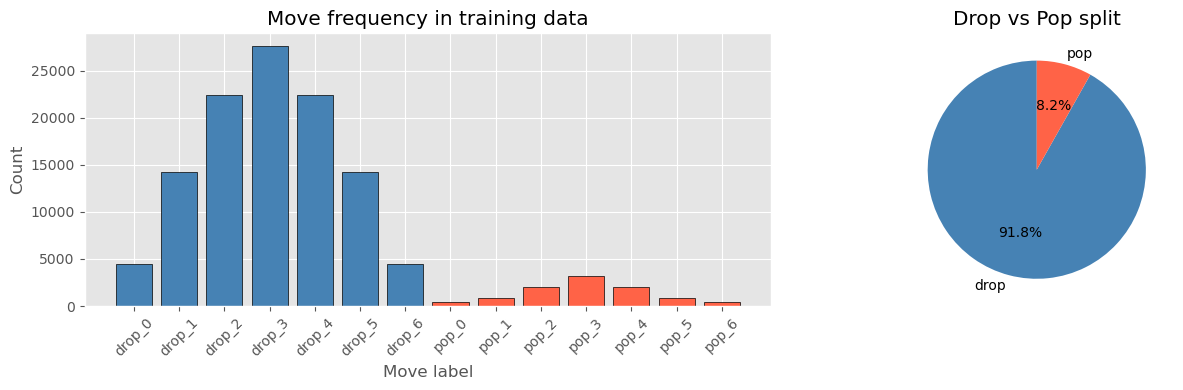

Drop moves: 109896 (91.8%)   Pop moves: 9780 (8.2%)


In [56]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training & Evaluation

Two ID3 trees are trained per version:

- **ID3 (features)** — all engineered features (`threats`, `phase`, `center`, etc.) plus raw cells
- **ID3 Raw** — raw cell occupancy values and `current_player` only; no hand-crafted features

Both use the same `ID3Classifier` from `src/decision_tree/id3/learner.py`.
Depth and oversampling factors come from `MODEL_CONFIGS` for the active version.

Proven positions (positions where the oracle found a forced win/loss) are
oversampled during training so the tree sees enough decisive examples.


## 3.1 Methodological note — train/test split leakage

The original split code

```python
df_train = df.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df.drop(df_train.index).reset_index(drop=True)
```

contains a subtle bug: `reset_index(drop=True)` overwrites the sampled indices,
so `drop(df_train.index)` removes the **first 80 % of rows by position** rather
than the sampled rows. The result is that `df_train` and `df_test` share most rows.

To measure generalisation honestly we evaluate under **three splits**:

| Split | What it is | What it tests |
|---|---|---|
| **BUGGY** | the original broken split | how inflated the originally-reported accuracy was |
| **RANDOM** | correct row-level 80/20 | row-level generalisation (still affected by mirrored duplicate rows) |
| **GROUPED** | unique board states split 80/20, rows assigned accordingly | true state-level generalisation — no board state appears in both train and test |

**GROUPED is the canonical split** used for the feature sweep and all downstream analysis.


In [57]:
# ── Safety guard: re-read saved results if toggle cell wasn't re-run ────────
if _saved_accuracy is None and _acc_path.exists():
    with open(_acc_path) as _f:
        _saved_accuracy = _json.load(_f)
    print(f'[guard] Loaded pre-saved accuracy results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')
if _saved_sweep is None and _sweep_path.exists():
    with open(_sweep_path) as _f:
        _saved_sweep = _json.load(_f)
    print(f'[guard] Loaded pre-saved sweep results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')
if _saved_winrate is None and _winrate_path.exists():
    with open(_winrate_path) as _f:
        _saved_winrate = _json.load(_f)
    print(f'[guard] Loaded pre-saved win-rate results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')

OVERSAMPLE_FACTOR = 4

# Raw model: cell features only — no engineered columns — compensated by greater depth
RAW_FEAT_EXCLUDE = {'threats_me', 'threats_opp', 'center_me', 'center_opp',
                    'phase', 'can_win', 'opp_wins_next'}
# FEAT_DEPTH and RAW_DEPTH come from the model toggle cell above
RAW_FEATURE_COLS = [c for c in FEATURE_COLS if c not in RAW_FEAT_EXCLUDE]

_need_data_prep = _saved_accuracy is None or _saved_sweep is None
if _need_data_prep:
    # Convert integer features to string for ID3Classifier
    df_str = df.copy()
    for col in FEATURE_COLS:
        df_str[col] = df_str[col].astype(str)
    
    # Filter can_win=1 — _forced_move handles those during play for both models
    if FILTER_CAN_WIN:
        df_str_train = df_str[df_str["can_win"].astype(str) != "1"].reset_index(drop=True)
        print(f"Filtered out {len(df_str) - len(df_str_train):,} can_win=1 positions "
              f"({(len(df_str) - len(df_str_train))/len(df_str):.1%} of dataset)")
    else:
        df_str_train = df_str.reset_index(drop=True)
        print("can_win=1 filter not applied for this version")
    print()
    
    import numpy as np
    
    # (1) BUGGY — original split with reset_index bug
    df_train_buggy = df_str_train.sample(frac=0.8, random_state=42).reset_index(drop=True)
    df_test_buggy  = df_str_train.drop(df_train_buggy.index).reset_index(drop=True)
    
    # (2) RANDOM — correct row-level 80/20
    df_train_random = df_str_train.sample(frac=0.8, random_state=42)
    df_test_random  = df_str_train.drop(df_train_random.index)
    
    # (3) GROUPED — state-aware: no board state appears in both train and test
    _rng = np.random.default_rng(seed=42)
    _unique_states  = sorted(set(map(tuple, df_str_train[FEATURE_COLS].values)))
    _rng.shuffle(_unique_states)
    _n_train_states = int(0.8 * len(_unique_states))
    _train_state_set = set(_unique_states[:_n_train_states])
    _sig = df_str_train[FEATURE_COLS].apply(tuple, axis=1)
    df_train_grouped = df_str_train[ _sig.isin(_train_state_set)].reset_index(drop=True)
    df_test_grouped  = df_str_train[~_sig.isin(_train_state_set)].reset_index(drop=True)
    
    SPLIT_PAIRS = [
        ('BUGGY',   df_train_buggy,   df_test_buggy),
        ('RANDOM',  df_train_random,  df_test_random),
        ('GROUPED', df_train_grouped, df_test_grouped),
    ]
    
    def _state_overlap(d_train, d_test):
        train_sigs = set(map(tuple, d_train[FEATURE_COLS].values))
        test_sigs  = list(map(tuple, d_test[FEATURE_COLS].values))
        return sum(1 for s in test_sigs if s in train_sigs) / len(test_sigs)
    
    ov = {name: _state_overlap(d_tr, d_te) for name, d_tr, d_te in SPLIT_PAIRS}
else:
    df_train_grouped = df_test_grouped = None
    SPLIT_PAIRS = [(n, None, None) for n in ("BUGGY", "RANDOM", "GROUPED")]
    ov = {n: _saved_accuracy["splits"][n]["overlap"] for n in ("BUGGY", "RANDOM", "GROUPED")}
    print(f"All results pre-saved — skipping data prep ({ACTIVE_MODEL}).")


def _train_and_eval(d_tr, d_te, feature_cols, max_depth, oversample=OVERSAMPLE_FACTOR):
    proven = d_tr[d_tr["is_proven"].astype(str) == "1"]
    d_aug  = pd.concat([d_tr] + [proven] * oversample, ignore_index=True)
    clf    = ID3Classifier(max_depth=max_depth)
    t0     = time.perf_counter()
    clf.fit(d_aug[feature_cols + [TARGET]], target=TARGET)
    elapsed = time.perf_counter() - t0
    return clf, clf.score(d_tr[feature_cols + [TARGET]], target=TARGET), \
               clf.score(d_te[feature_cols + [TARGET]], target=TARGET), elapsed

def _tactical_breakdown(clf, d_test, feature_cols):
    preds   = clf.predict(d_test[feature_cols])
    correct = (preds == d_test[TARGET].astype(str))
    result  = {}
    opp_mask = d_test["opp_wins_next"].astype(str) == "1"
    if opp_mask.sum() > 0:
        result['opp_wins_next'] = {'n': int(opp_mask.sum()), 'accuracy': float(correct[opp_mask].mean())}
    pop_mask = d_test[TARGET].str.startswith("pop")
    if pop_mask.sum() > 0:
        result['pop_moves'] = {'n': int(pop_mask.sum()), 'accuracy': float(correct[pop_mask].mean())}
    return result

if _saved_accuracy is not None:
    # ── Load pre-saved results ────────────────────────────────────────────────
    print(f"Pre-saved accuracy results loaded for {ACTIVE_MODEL} ({VERSION}) — skipping retraining.")
    _s = _saved_accuracy['splits']
    _feat_acc = {k: (_s[k]['feat']['train_acc'], _s[k]['feat']['test_acc'], _s[k]['feat']['time'])
                 for k in ('BUGGY', 'RANDOM', 'GROUPED')}
    _raw_acc  = {k: (_s[k]['raw']['train_acc'],  _s[k]['raw']['test_acc'],  _s[k]['raw']['time'])
                 for k in ('BUGGY', 'RANDOM', 'GROUPED')}
    _tactical     = _saved_accuracy.get('tactical', {})
    clf_full = clf_full_raw = None
else:
    # ── Compute from scratch ──────────────────────────────────────────────────
    print(f"Training ID3 — feat (depth={FEAT_DEPTH}) and raw (depth={RAW_DEPTH}) — under each split ...")
    print()
    _feat_acc = {}
    _raw_acc  = {}
    _clfs     = {}
    for split_name, d_tr, d_te in SPLIT_PAIRS:
        print(f"  {split_name:<7}  ({len(d_tr):>6,} train / {len(d_te):>6,} test)")
        clf_f, f_tr, f_te, t_f = _train_and_eval(d_tr, d_te, FEATURE_COLS,     max_depth=FEAT_DEPTH)
        clf_r, r_tr, r_te, t_r = _train_and_eval(d_tr, d_te, RAW_FEATURE_COLS, max_depth=RAW_DEPTH, oversample=RAW_OVERSAMPLE)
        print(f"    feat d={FEAT_DEPTH} : train={f_tr:.3f}  test={f_te:.3f}  ({t_f:.1f}s)")
        print(f"    raw  d={RAW_DEPTH} : train={r_tr:.3f}  test={r_te:.3f}  ({t_r:.1f}s)")
        _feat_acc[split_name] = (f_tr, f_te, t_f)
        _raw_acc[split_name]  = (r_tr, r_te, t_r)
        _clfs[split_name]     = (clf_f, clf_r)
        print()

    clf_full     = _clfs['GROUPED'][0]
    clf_full_raw = _clfs['GROUPED'][1]
    _tactical    = {
        'feat': _tactical_breakdown(clf_full,     df_test_grouped, FEATURE_COLS),
        'raw':  _tactical_breakdown(clf_full_raw, df_test_grouped, RAW_FEATURE_COLS),
    }

    # ── Save ──────────────────────────────────────────────────────────────────
    _acc_data = {
        'version': VERSION,
        'splits': {
            split_name: {
                'train_rows': len(d_tr), 'test_rows': len(d_te), 'overlap': ov[split_name],
                'feat': {'train_acc': _feat_acc[split_name][0], 'test_acc': _feat_acc[split_name][1],
                         'time':      _feat_acc[split_name][2]},
                'raw':  {'train_acc': _raw_acc[split_name][0],  'test_acc': _raw_acc[split_name][1],
                         'time':      _raw_acc[split_name][2]},
            }
            for split_name, d_tr, d_te in SPLIT_PAIRS
        },
        'tactical': _tactical,
    }
    _acc_data['feature_importance'] = {
        'feat': clf_full.get_feature_importance(),
        'raw':  clf_full_raw.get_feature_importance(),
    }
    _acc_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_acc_path, 'w') as _f:
        _json.dump(_acc_data, _f, indent=2)
    print(f'Accuracy results saved → {_acc_path}')

# ── Comparison table ──────────────────────────────────────────────────────────
print()
_H = (f"{'Split':<10} {'rows(tr/te)':>15} {'overlap':>8}  "
      f"{'feat_train':>10} {'feat_test':>9} {'Δ':>6}  "
      f"{'raw_train':>9} {'raw_test':>8} {'Δ':>6}")
print("=" * len(_H))
print(_H)
print("-" * len(_H))
for split_name, d_tr, d_te in SPLIT_PAIRS:
    f_tr, f_te, _ = _feat_acc[split_name]
    r_tr, r_te, _ = _raw_acc[split_name]
    _tr_n = len(d_tr) if d_tr is not None else _saved_accuracy["splits"][split_name]["train_rows"]
    _te_n = len(d_te) if d_te is not None else _saved_accuracy["splits"][split_name]["test_rows"]
    print(f"{split_name:<10} {_tr_n:>7,}/{_te_n:<7,} {ov[split_name]:>8.1%}  "
          f"{f_tr:>10.3f} {f_te:>9.3f} {f_tr-f_te:>+6.3f}  "
          f"{r_tr:>9.3f} {r_te:>8.3f} {r_tr-r_te:>+6.3f}")
print("=" * len(_H))

f_g_tr, f_g_te, _ = _feat_acc['GROUPED']
r_g_tr, r_g_te, _ = _raw_acc['GROUPED']
print()
print("Interpretation (GROUPED split — no data leakage):")
print(f"  feat  generalisation gap: {f_g_tr - f_g_te:+.3f}  (train={f_g_tr:.3f}  test={f_g_te:.3f})")
print(f"  raw   generalisation gap: {r_g_tr - r_g_te:+.3f}  (train={r_g_tr:.3f}  test={r_g_te:.3f})")
print()
print("→ GROUPED is the canonical split for downstream analysis.")

# ── Set canonical variables for downstream cells ──────────────────────────────
if _need_data_prep:
    df_train     = df_train_grouped
    df_test      = df_test_grouped
    proven       = df_train[df_train["is_proven"].astype(str) == "1"]
    df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR, ignore_index=True)
else:
    df_train = df_test = df_train_aug = None

# ── Tactical breakdown ────────────────────────────────────────────────────────
for variant_label, variant_key in [('ID3 (features)', 'feat'), ('ID3 Raw', 'raw')]:
    tac = _tactical.get(variant_key, {})
    if not tac:
        continue
    suffix = '' if clf_full is not None else '  (pre-saved)'
    print(f"\nTactical accuracy — {variant_label}:")
    if 'opp_wins_next' in tac:
        v = tac['opp_wins_next']
        print(f"  opp_wins_next=1  (n={v['n']:4d}): {v['accuracy']:.3f}{suffix}")
    if 'pop_moves' in tac:
        v = tac['pop_moves']
        print(f"  pop moves        (n={v['n']:4d}): {v['accuracy']:.3f}{suffix}")

All results pre-saved — skipping data prep (v1).
Pre-saved accuracy results loaded for v1 (v1_3000games_100k) — skipping retraining.

Split          rows(tr/te)  overlap  feat_train feat_test      Δ  raw_train raw_test      Δ
-------------------------------------------------------------------------------------------
BUGGY       95,741/23,935     98.7%       0.854     0.843 +0.011      0.855    0.846 +0.010
RANDOM      95,741/23,935     93.9%       0.854     0.798 +0.056      0.855    0.803 +0.053
GROUPED     99,467/20,209      0.0%       0.863     0.404 +0.460      0.865    0.576 +0.289

Interpretation (GROUPED split — no data leakage):
  feat  generalisation gap: +0.460  (train=0.863  test=0.404)
  raw   generalisation gap: +0.289  (train=0.865  test=0.576)

→ GROUPED is the canonical split for downstream analysis.

Tactical accuracy — ID3 (features):
  opp_wins_next=1  (n=2807): 0.388  (pre-saved)
  pop moves        (n=1748): 0.510  (pre-saved)

Tactical accuracy — ID3 Raw:
  opp_win

In [58]:
if clf_full is not None:
    # Fresh computation — importances come straight from the trained classifiers
    _importances = {
        'feat': clf_full.get_feature_importance(),
        'raw':  clf_full_raw.get_feature_importance(),
    }
elif _saved_accuracy and 'feature_importance' in _saved_accuracy:
    # Already stored in the JSON — load directly
    _importances = _saved_accuracy['feature_importance']
else:
    # Saved file predates this feature — retrain GROUPED models only and update the file
    print("Feature importance not in saved file — retraining GROUPED models (one-time cost)...")
    _proven_g = df_train[df_train["is_proven"].astype(str) == "1"]
    _aug_g    = pd.concat([df_train] + [_proven_g] * OVERSAMPLE_FACTOR, ignore_index=True)
    _clf_f = ID3Classifier(max_depth=FEAT_DEPTH)
    _clf_f.fit(_aug_g[FEATURE_COLS + [TARGET]], target=TARGET)
    _clf_r = ID3Classifier(max_depth=RAW_DEPTH)
    _clf_r.fit(_aug_g[RAW_FEATURE_COLS + [TARGET]], target=TARGET)
    _importances = {
        'feat': _clf_f.get_feature_importance(),
        'raw':  _clf_r.get_feature_importance(),
    }
    _saved_accuracy['feature_importance'] = _importances
    with open(_acc_path, 'w') as _f:
        _json.dump(_saved_accuracy, _f, indent=2)
    print(f'Saved file updated with feature importance \u2192 {_acc_path}')



## 4. Feature Sweep

Features are ranked by their **information gain** on the GROUPED training set.
We then train separate ID3 trees using only the top-K features and measure
train and test accuracy as K increases.

The curve shows:
1. How model capacity grows with the number of features available
2. The true marginal value of each additional feature for generalisation
   (GROUPED ensures there is no leakage inflating the test numbers)


Pre-saved sweep results loaded for v1 — skipping IG computation.
Top 10 features by IG — ID3 (features):
   1. center_me           IG = 0.7518
   2. center_opp          IG = 0.6649
   3. cell_3_3            IG = 0.5142
   4. phase               IG = 0.3909
   5. cell_2_3            IG = 0.3779
   6. cell_0_2            IG = 0.3737
   7. cell_0_4            IG = 0.3676
   8. cell_1_4            IG = 0.2881
   9. cell_1_2            IG = 0.2724
  10. cell_2_4            IG = 0.2493

Top 10 features by IG — ID3 Raw:
   1. cell_3_3            IG = 0.5142
   2. cell_2_3            IG = 0.3779
   3. cell_0_2            IG = 0.3737
   4. cell_0_4            IG = 0.3676
   5. cell_1_4            IG = 0.2881
   6. cell_1_2            IG = 0.2724
   7. cell_2_4            IG = 0.2493
   8. cell_1_3            IG = 0.2369
   9. cell_2_2            IG = 0.2315
  10. cell_0_5            IG = 0.2305


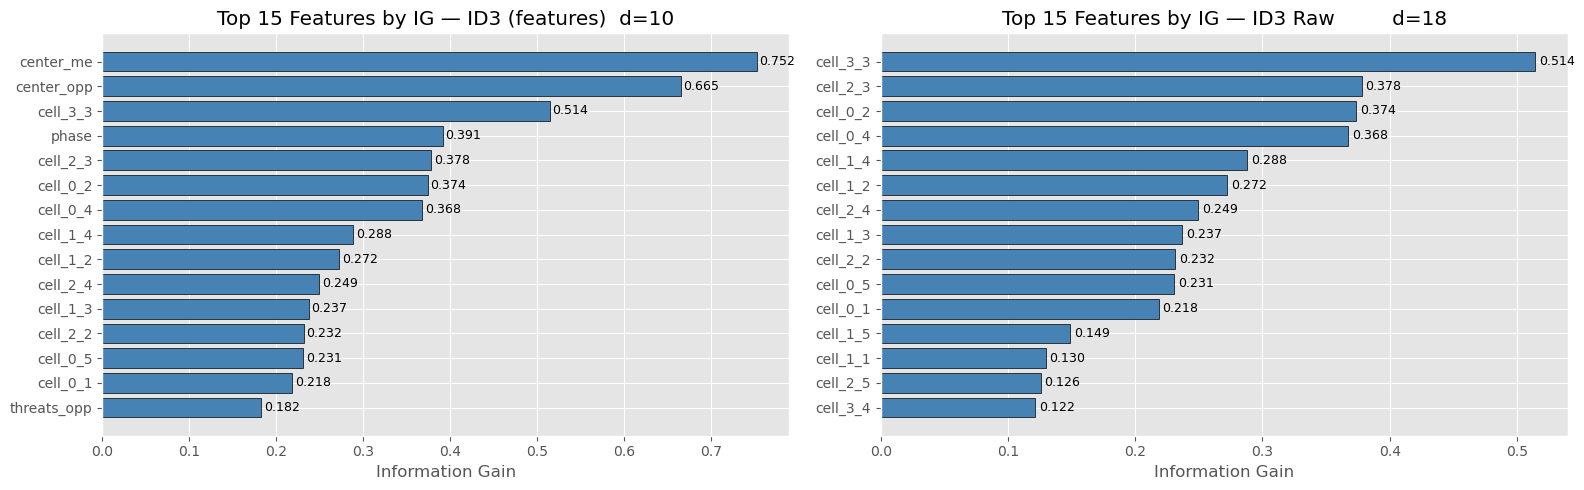

In [59]:
if _saved_sweep is not None:
    print(f"Pre-saved sweep results loaded for {ACTIVE_MODEL} — skipping IG computation.")
    ranked_feat    = _saved_sweep['feat']['ranked_features']
    ig_scores_feat = _saved_sweep['feat']['ig_scores']
    ranked_raw     = _saved_sweep['raw']['ranked_features']
    ig_scores_raw  = _saved_sweep['raw']['ig_scores']
else:
    _ranker = ID3Classifier()
    ig_scores_feat = {f: _ranker.information_gain(df_train, f, TARGET) for f in FEATURE_COLS}
    ranked_feat    = sorted(ig_scores_feat, key=ig_scores_feat.get, reverse=True)
    ig_scores_raw  = {f: _ranker.information_gain(df_train, f, TARGET) for f in RAW_FEATURE_COLS}
    ranked_raw     = sorted(ig_scores_raw,  key=ig_scores_raw.get,  reverse=True)

ranked_features = ranked_feat  # backward-compat alias used by downstream cells

print('Top 10 features by IG — ID3 (features):')
for i, f in enumerate(ranked_feat[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores_feat[f]:.4f}')

print()
print('Top 10 features by IG — ID3 Raw:')
for i, f in enumerate(ranked_raw[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores_raw[f]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_n = 15
for ax, ranked, ig_scores, title in [
    (axes[0], ranked_feat, ig_scores_feat, f'ID3 (features)  d={FEAT_DEPTH}'),
    (axes[1], ranked_raw,  ig_scores_raw,  f'ID3 Raw         d={RAW_DEPTH}'),
]:
    feats  = ranked[:top_n]
    scores = [ig_scores[f] for f in feats]
    bars = ax.barh(feats[::-1], scores[::-1], color='steelblue', edgecolor='black')
    for bar, val in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Information Gain')
    ax.set_title(f'Top {top_n} Features by IG — {title}')
plt.tight_layout()
plt.show()

In [60]:
K_VALUES_FEAT = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
K_VALUES_RAW  = [1, 3, 5, 10, 15, 20, 30, len(RAW_FEATURE_COLS)]

if _saved_sweep is not None:
    print(f"Pre-saved sweep results loaded for {ACTIVE_MODEL} — skipping sweep computation.")
    sweep_df_feat = pd.DataFrame(_saved_sweep['feat']['sweep'])
    sweep_df_raw  = pd.DataFrame(_saved_sweep['raw']['sweep'])
else:
    def _run_sweep(ranked, k_values, depth, label):
        results = []
        print(f"Feature sweep — {label} (depth={depth})")
        for k in k_values:
            cols  = ranked[:k] + [TARGET]
            clf_k = ID3Classifier(max_depth=depth)
            clf_k.fit(df_train[cols], target=TARGET)
            tr = clf_k.score(df_train[cols], target=TARGET)
            te = clf_k.score(df_test[cols],  target=TARGET)
            results.append({'K': k, 'train': tr, 'test': te})
            print(f'  K={k:3d}  train={tr:.3f}  test={te:.3f}')
        return results

    sweep_results_feat = _run_sweep(ranked_feat, K_VALUES_FEAT, FEAT_DEPTH, 'ID3 (features)')
    print()
    sweep_results_raw  = _run_sweep(ranked_raw,  K_VALUES_RAW,  RAW_DEPTH,  'ID3 Raw')

    sweep_df_feat = pd.DataFrame(sweep_results_feat)
    sweep_df_raw  = pd.DataFrame(sweep_results_raw)

    _sweep_data = {
        'version':    VERSION,
        'feat_depth': FEAT_DEPTH,
        'raw_depth':  RAW_DEPTH,
        'feat': {
            'ranked_features': ranked_feat,
            'ig_scores':       ig_scores_feat,
            'k_values':        K_VALUES_FEAT,
            'sweep':           sweep_results_feat,
        },
        'raw': {
            'ranked_features': ranked_raw,
            'ig_scores':       ig_scores_raw,
            'k_values':        K_VALUES_RAW,
            'sweep':           sweep_results_raw,
        },
    }
    _sweep_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_sweep_path, 'w') as _f:
        _json.dump(_sweep_data, _f, indent=2)
    print(f'\nSweep results saved → {_sweep_path}')

sweep_df = sweep_df_feat  # backward-compat alias

Pre-saved sweep results loaded for v1 — skipping sweep computation.


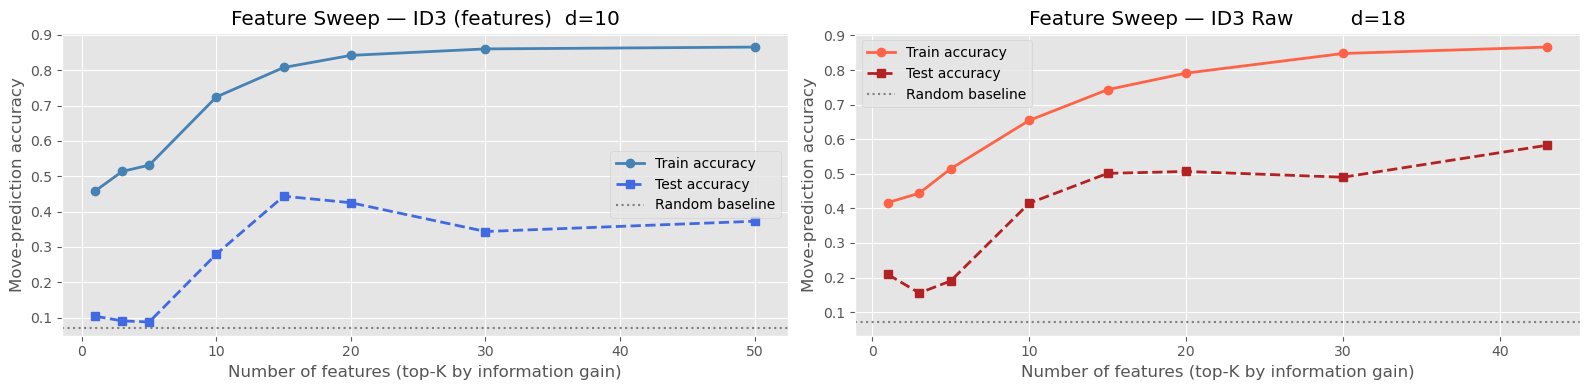

In [61]:
_random_baseline = 1 / df[TARGET].nunique()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, sdf, title, c_tr, c_te in [
    (axes[0], sweep_df_feat, f'ID3 (features)  d={FEAT_DEPTH}', 'steelblue', 'royalblue'),
    (axes[1], sweep_df_raw,  f'ID3 Raw         d={RAW_DEPTH}',  'tomato',    'firebrick'),
]:
    ax.plot(sdf['K'], sdf['train'], 'o-',  label='Train accuracy', color=c_tr, linewidth=2)
    ax.plot(sdf['K'], sdf['test'],  's--', label='Test accuracy',  color=c_te, linewidth=2)
    ax.axhline(_random_baseline, color='gray', linestyle=':', label='Random baseline')
    ax.set_xlabel('Number of features (top-K by information gain)')
    ax.set_ylabel('Move-prediction accuracy')
    ax.set_title(f'Feature Sweep — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

### Feature-sweep discussion

Three consistent patterns appear across versions:

1. **Train accuracy grows with K** — the tree has capacity to memorise the training set.
2. **Test accuracy plateaus early** — most of the generalisable signal is concentrated
   in the top ~15 features (centre control, phase, central column cells, opponent threats).
   Features beyond that point add almost nothing for unseen positions.
3. **At very low K, test accuracy can exceed train accuracy.** This is an artefact of
   proven-position oversampling: the train distribution is artificially inflated, while
   the test set reflects the natural distribution. A shallow tree that learns one robust
   rule (e.g. split on `center_me`) fits the natural test distribution slightly better
   than the skewed training one. The effect disappears as K grows and the tree begins
   memorising specific board configurations.

The train/test gap at full K reflects a clear **high-variance** regime: the tree
memorises training positions but only a fraction of that signal transfers to unseen
states. The GROUPED test accuracy is nonetheless well above trivial baselines
(random over 14 classes ≈ 7 %, always-`drop_3` ≈ 28 %).


## 5. Win-Rate Evaluation

The trained trees are evaluated against two MCTS engine families at multiple
iteration counts, playing 100 games per configuration with alternating sides.

| Engine | Notes |
|---|---|
| **FlatNumbaMCTS** | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | MCTS-Solver — exits early when a position is proven |

Moves are selected through the full `ID3Agent` / `ID3AgentRaw` wrappers, which
apply the `_forced_move` rule layer (immediate win / block) before consulting
the tree.

Four tree variants are tested: featured and raw, each in wrapped and pure (no
`_forced_move`) mode. The pure variant isolates the tree's own decision quality.


In [62]:
import pickle, gc

import ctypes as _ct
# Free memory from earlier cells before heavy training
_gns = globals()
for _v in ['df_str', 'df_str_train', 'df_train', 'df_test', 'df_train_aug',
           'clf_full', 'clf_k', 'sweep_df', 'sweep_results', '_ranker', 'ig_scores', 'ranked_features']:
    _gns.pop(_v, None)
del _gns
gc.collect()
try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
except: pass

PICKLE_PATH     = Path(f'../data/generated/{VERSION}/id3_model.pkl')
PICKLE_RAW_PATH = Path(f'../data/generated/{VERSION}/id3_model_raw.pkl')

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
# RAW_DEPTH comes from the model toggle cell above

# ── ID3 with engineered features ─────────────────────────────────────────────
if PICKLE_PATH.exists():
    print(f'Loading clf_game from {PICKLE_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_PATH, 'rb') as f:
        clf_game = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'Training clf_game on full dataset (features, depth={FEAT_DEPTH}, 4x proven oversampling)...')
    if FILTER_CAN_WIN:
        _df = df[df['can_win'] != 1].reset_index(drop=True)
        print(f'  After can_win=1 filter: {len(_df):,} rows')
    else:
        _df = df.copy()
    _feat_cols = [c for c in _df.columns if c not in ('best_move', 'is_proven')]
    if 'is_proven' in _df.columns:
        _proven = _df[_df['is_proven'] == 1]
        _df = pd.concat([_df] + [_proven] * 4, ignore_index=True)
        del _proven
    for c in _feat_cols: _df[c] = _df[c].astype(str)
    _df['best_move'] = _df['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game = ID3Classifier(max_depth=FEAT_DEPTH)
    clf_game.fit(_df[_feat_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df; gc.collect()
    try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
    except: pass
    PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f: pickle.dump(clf_game, f)
    print(f'  Saved to {PICKLE_PATH}')

# ── ID3 Raw (raw cells only, proven oversampling) ─────────────────────────────
if PICKLE_RAW_PATH.exists():
    print(f'\nLoading clf_game_raw from {PICKLE_RAW_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_RAW_PATH, 'rb') as f:
        clf_game_raw = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'\nTraining clf_game_raw (raw cells, depth={RAW_DEPTH}, {RAW_OVERSAMPLE}x proven)...')
    if FILTER_CAN_WIN:
        _df_raw = df[df['can_win'] != 1].reset_index(drop=True)
        print(f'  After can_win=1 filter: {len(_df_raw):,} rows')
    else:
        _df_raw = df.copy()
    _raw_cols = [c for c in _df_raw.columns if c not in _EXCLUDE_RAW]
    if 'is_proven' in _df_raw.columns:
        _proven = _df_raw[_df_raw['is_proven'] == 1]
        _df_raw = pd.concat([_df_raw] + [_proven] * RAW_OVERSAMPLE, ignore_index=True)
        del _proven
    for c in _raw_cols: _df_raw[c] = _df_raw[c].astype(str)
    _df_raw['best_move'] = _df_raw['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game_raw = ID3Classifier(max_depth=RAW_DEPTH)
    clf_game_raw.fit(_df_raw[_raw_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df_raw; gc.collect()
    PICKLE_RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_RAW_PATH, 'wb') as f: pickle.dump(clf_game_raw, f)
    print(f'  Saved to {PICKLE_RAW_PATH}')


Loading clf_game from ../data/generated/v1_3000games_100k/id3_model.pkl ...
  Loaded in 0.04s

Loading clf_game_raw from ../data/generated/v1_3000games_100k/id3_model_raw.pkl ...
  Loaded in 0.39s


In [63]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.0 s


In [64]:
import types
from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

def _make_tree_agent(clf, raw=False):
    """Wrap classifier in the agent class — includes _forced_move."""
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf
    return agent

def _make_tree_agent_pure(clf, raw=False):
    """Wrap classifier without _forced_move — pure tree prediction only.

    Matches exactly what the accuracy test measures: the tree's own prediction
    with no immediate-win/block rule applied beforehand.
    """
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf

    if raw:
        def _run(self, board, iterations=0):
            row = pd.Series({k: str(v) for k, v in board.to_feature_dict().items()})
            return self._parse_move(self._classifier.predict_one(row), board.legal_moves())
    else:
        def _run(self, board, iterations=0):
            features = extended_features(board)
            row = pd.Series({k: str(v) for k, v in features.items() if k != 'is_proven'})
            return self._parse_move(self._classifier.predict_one(row), board.legal_moves())

    agent.run = types.MethodType(_run, agent)
    return agent

def play_one_game(tree_agent, mcts_agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game. Returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        if mover == tree_plays_as:
            move = tree_agent.run(board)
        else:
            move = mcts_agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [65]:
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor, as_completed
from src.decision_tree.game_eval import _init_eval_worker, eval_config

EVAL_GAMES     = 100
_GAMES_PER_SIDE = EVAL_GAMES // 2   # half as P1, half as P2
N_WORKERS      = 20

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

TREE_MODELS = {
    'ID3 (features)':      _make_tree_agent(     clf_game,     raw=False),
    'ID3 Raw':             _make_tree_agent(     clf_game_raw, raw=True),
    'ID3 (features) pure': _make_tree_agent_pure(clf_game,     raw=False),
    'ID3 Raw pure':        _make_tree_agent_pure(clf_game_raw, raw=True),
}

# Spec passed to worker: (is_raw, is_pure) — no large objects cross the boundary
_MODEL_SPEC = {
    'ID3 (features)':      (False, False),
    'ID3 Raw':             (True,  False),
    'ID3 (features) pure': (False, True),
    'ID3 Raw pure':        (True,  True),
}

if _saved_winrate is not None:
    # ── Load pre-saved results ────────────────────────────────────────────────
    eval_results = {}
    for model_name, engines in _saved_winrate['results'].items():
        for engine_name, iters_dict in engines.items():
            for iters_str, wld in iters_dict.items():
                eval_results[(model_name, engine_name, int(iters_str))] = tuple(wld)
    print(f"Pre-saved win-rate results loaded for {ACTIVE_MODEL} ({VERSION}) — skipping game evaluation.\n")
    for model_name in TREE_MODELS:
        print(f'\n── {model_name} ──')
        for engine_name, iter_list in CONFIGS.items():
            for iters in iter_list:
                r = eval_results[(model_name, engine_name, iters)]
                if len(r) == 6:
                    w_p1, l_p1, d_p1, w_p2, l_p2, d_p2 = r
                    print(f'  {engine_name:22s}  {iters:7,d} iter  '
                          f'->  P1: {w_p1/_GAMES_PER_SIDE:5.1%} ({w_p1}W/{l_p1}L/{d_p1}D)  '
                          f'P2: {w_p2/_GAMES_PER_SIDE:5.1%} ({w_p2}W/{l_p2}L/{d_p2}D)')
                else:
                    w, l, d = r
                    print(f'  {engine_name:22s}  {iters:7,d} iter  ->  {w/EVAL_GAMES:5.1%}  '
                          f'({w}W / {l}L / {d}D)  [legacy — delete saved file to get P1/P2 split]')
            print()
else:
    # ── Parallel evaluation ───────────────────────────────────────────────────
    _tasks = [
        (mn, en, it)
        for mn in TREE_MODELS
        for en, iter_list in CONFIGS.items()
        for it in iter_list
    ]
    print(f'Running {len(_tasks)} configs × {EVAL_GAMES} games on {N_WORKERS} workers ...\n')
    t0 = time.perf_counter()
    eval_results = {}

    with ProcessPoolExecutor(
        max_workers=N_WORKERS,
        initializer=_init_eval_worker,
        initargs=(str(PICKLE_PATH), str(PICKLE_RAW_PATH)),
        mp_context=_mp.get_context('spawn'),
    ) as _pool:
        _futures = {
            _pool.submit(
                eval_config,
                *_MODEL_SPEC[mn], en, it, EVAL_GAMES,
                abs(hash((mn, en, it))) % (2**31),
            ): (mn, en, it)
            for mn, en, it in _tasks
        }
        for _fut in as_completed(_futures):
            mn, en, it = _futures[_fut]
            w_p1, l_p1, d_p1, w_p2, l_p2, d_p2 = _fut.result()
            eval_results[(mn, en, it)] = (w_p1, l_p1, d_p1, w_p2, l_p2, d_p2)
            print(f'{mn:<25}  {en:<22}  {it:>7,}  '
                  f'P1: {w_p1/_GAMES_PER_SIDE:5.1%} ({w_p1}W/{l_p1}L/{d_p1}D)  '
                  f'P2: {w_p2/_GAMES_PER_SIDE:5.1%} ({w_p2}W/{l_p2}L/{d_p2}D)')

    print(f'\nTotal evaluation time: {time.perf_counter()-t0:.1f}s')

    _wr_data = {
        'version':    VERSION,
        'eval_games': EVAL_GAMES,
        'results': {
            model_name: {
                engine_name: {str(it): list(eval_results[(model_name, engine_name, it)])
                               for it in iter_list}
                for engine_name, iter_list in CONFIGS.items()
            }
            for model_name in TREE_MODELS
        }
    }
    _winrate_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_winrate_path, 'w') as _f:
        _json.dump(_wr_data, _f, indent=2)
    print(f'Win-rate results saved -> {_winrate_path}')


Running 40 configs × 100 games on 20 workers ...

ID3 (features)             FlatNumbaMCTS               100  P1: 98.0% (49W/1L/0D)  P2: 72.0% (36W/14L/0D)
ID3 Raw                    FlatNumbaMCTS               100  P1: 96.0% (48W/2L/0D)  P2: 68.0% (34W/16L/0D)
ID3 (features) pure        FlatNumbaMCTS               100  P1: 42.0% (21W/29L/0D)  P2: 20.0% (10W/40L/0D)
ID3 Raw                    FlatNumbaMCTS               500  P1: 78.0% (39W/11L/0D)  P2: 34.0% (17W/33L/0D)
ID3 (features)             FlatNumbaMCTS               500  P1: 78.0% (39W/11L/0D)  P2: 42.0% (21W/29L/0D)
ID3 (features) pure        FlatNumbaMCTS               500  P1: 28.0% (14W/36L/0D)  P2:  6.0% (3W/47L/0D)
ID3 (features)             FlatNumbaMCTS             1,000  P1: 58.0% (29W/21L/0D)  P2: 20.0% (10W/40L/0D)
ID3 Raw                    FlatNumbaMCTS             1,000  P1: 72.0% (36W/14L/0D)  P2: 32.0% (16W/33L/1D)
ID3 (features)             FlatNumbaSolverMCTS       1,000  P1: 60.0% (30W/20L/0D)  P2: 18.0% (9W

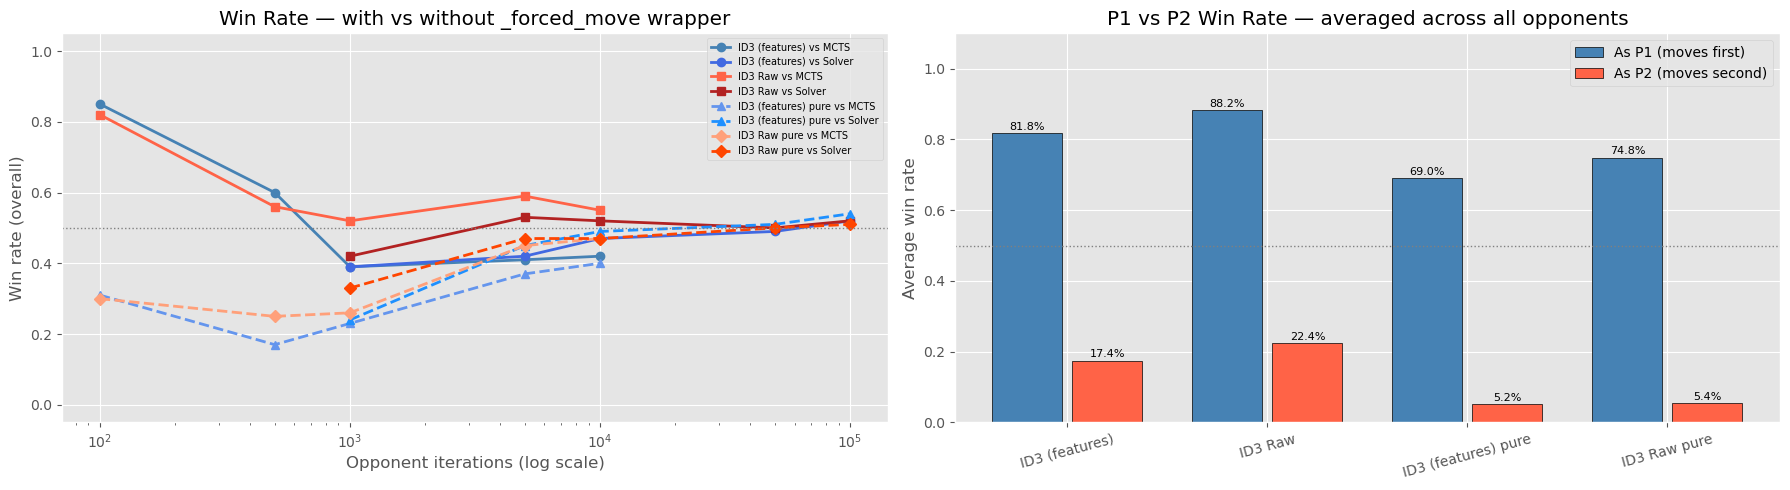


Model                      Opponent engine              Iters   P1 Win%   P2 Win%    P1 W/L/D    P2 W/L/D
------------------------------------------------------------------------------------------------------
ID3 (features)             FlatNumbaMCTS                  100     98.0%     72.0%   49/1  /0     36/14 /0  
ID3 (features)             FlatNumbaMCTS                  500     78.0%     42.0%   39/11 /0     21/29 /0  
ID3 (features)             FlatNumbaMCTS                1,000     58.0%     20.0%   29/21 /0     10/40 /0  
ID3 (features)             FlatNumbaMCTS                5,000     78.0%      4.0%   39/11 /0      2/48 /0  
ID3 (features)             FlatNumbaMCTS               10,000     80.0%      4.0%   40/10 /0      2/48 /0  
ID3 (features)             FlatNumbaSolverMCTS          1,000     60.0%     18.0%   30/20 /0      9/41 /0  
ID3 (features)             FlatNumbaSolverMCTS          5,000     76.0%      8.0%   38/12 /0      4/46 /0  
ID3 (features)             FlatNum

In [66]:
ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}

_MODEL_STYLE = {
    'ID3 (features)':      {'colors': {'FlatNumbaMCTS': 'steelblue',     'FlatNumbaSolverMCTS': 'royalblue'},   'marker': 'o', 'ls': '-'},
    'ID3 Raw':             {'colors': {'FlatNumbaMCTS': 'tomato',         'FlatNumbaSolverMCTS': 'firebrick'},   'marker': 's', 'ls': '-'},
    'ID3 (features) pure': {'colors': {'FlatNumbaMCTS': 'cornflowerblue', 'FlatNumbaSolverMCTS': 'dodgerblue'}, 'marker': '^', 'ls': '--'},
    'ID3 Raw pure':        {'colors': {'FlatNumbaMCTS': 'lightsalmon',    'FlatNumbaSolverMCTS': 'orangered'},   'marker': 'D', 'ls': '--'},
}

def _get_wr(result, side=None):
    """Win rate from a result tuple; handles 3-value (legacy) and 6-value formats."""
    if len(result) == 6:
        w_p1, l_p1, d_p1, w_p2, l_p2, d_p2 = result
        if side == 1: return w_p1 / _GAMES_PER_SIDE
        if side == 2: return w_p2 / _GAMES_PER_SIDE
        return (w_p1 + w_p2) / EVAL_GAMES
    w, l, d = result
    return w / EVAL_GAMES

_has_p1p2 = len(next(iter(eval_results.values()))) == 6

# ── Line chart: overall win rate vs opponent strength ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for model_name in TREE_MODELS:
    style = _MODEL_STYLE[model_name]
    for engine_name, iter_list in CONFIGS.items():
        win_rates = [_get_wr(eval_results[(model_name, engine_name, it)]) for it in iter_list]
        axes[0].plot(iter_list, win_rates,
                     marker=style['marker'], linestyle=style['ls'],
                     color=style['colors'][engine_name], linewidth=2,
                     label=f'{model_name} vs {ENGINE_SHORT[engine_name]}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('Win rate (overall)')
axes[0].set_title('Win Rate — with vs without _forced_move wrapper')
axes[0].set_ylim(-0.05, 1.05)
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[0].legend(fontsize=7)

# ── Grouped bar chart: P1 vs P2 win rate (averaged across all opponents) ──────
model_names = list(TREE_MODELS.keys())
xi = np.arange(len(model_names))

if _has_p1p2:
    avg_wr_p1 = [
        np.mean([_get_wr(eval_results[(m, eng, it)], side=1)
                 for eng, iters in CONFIGS.items() for it in iters])
        for m in model_names
    ]
    avg_wr_p2 = [
        np.mean([_get_wr(eval_results[(m, eng, it)], side=2)
                 for eng, iters in CONFIGS.items() for it in iters])
        for m in model_names
    ]
    bars1 = axes[1].bar(xi - 0.2, avg_wr_p1, 0.35,
                        label='As P1 (moves first)', color='steelblue', edgecolor='black')
    bars2 = axes[1].bar(xi + 0.2, avg_wr_p2, 0.35,
                        label='As P2 (moves second)', color='tomato', edgecolor='black')
    for bar, v in zip(bars1, avg_wr_p1):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{v:.1%}', ha='center', fontsize=8)
    for bar, v in zip(bars2, avg_wr_p2):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{v:.1%}', ha='center', fontsize=8)
    axes[1].set_title('P1 vs P2 Win Rate — averaged across all opponents')
    axes[1].legend()
else:
    avg_wr = [
        np.mean([_get_wr(eval_results[(m, eng, it)])
                 for eng, iters in CONFIGS.items() for it in iters])
        for m in model_names
    ]
    _BAR_COLORS = ['steelblue', 'tomato', 'cornflowerblue', 'lightsalmon']
    bars = axes[1].bar(model_names, avg_wr, color=_BAR_COLORS[:len(model_names)], edgecolor='black')
    for bar, v in zip(bars, avg_wr):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{v:.1%}', ha='center', fontsize=10)
    axes[1].set_title('Average Win Rate — all model variants  [legacy format]')

axes[1].set_xticks(xi)
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel('Average win rate')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

# ── Detailed results table ────────────────────────────────────────────────────
print()
if _has_p1p2:
    print(f'{"Model":<25}  {"Opponent engine":<22}  {"Iters":>10}  '
          f'{"P1 Win%":>8}  {"P2 Win%":>8}  {"P1 W/L/D":>10}  {"P2 W/L/D":>10}')
    print('-' * 102)
    for model_name in TREE_MODELS:
        for engine_name, iter_list in CONFIGS.items():
            for it in iter_list:
                w_p1, l_p1, d_p1, w_p2, l_p2, d_p2 = eval_results[(model_name, engine_name, it)]
                print(f'{model_name:<25}  {engine_name:<22}  {it:>10,}  '
                      f'{w_p1/_GAMES_PER_SIDE:>8.1%}  {w_p2/_GAMES_PER_SIDE:>8.1%}  '
                      f'{w_p1:>3}/{l_p1:<3}/{d_p1:<3}  {w_p2:>3}/{l_p2:<3}/{d_p2:<3}')
        print()
else:
    print(f'{"Model":<25}  {"Opponent engine":<22}  {"Iterations":>10}  {"Win%":>7}  {"W":>4}  {"L":>4}  {"D":>4}')
    print('-' * 78)
    for model_name in TREE_MODELS:
        for engine_name, iter_list in CONFIGS.items():
            for it in iter_list:
                w, l, d = eval_results[(model_name, engine_name, it)]
                print(f'{model_name:<25}  {engine_name:<22}  {it:>10,}  '
                      f'{w/EVAL_GAMES:>7.1%}  {w:>4}  {l:>4}  {d:>4}')
        print()


## 6. Summary — All Stored Results

Aggregates saved results across all four dataset versions without re-running games.
For each version, the per-version `results/` directory is read directly.

Win rates labelled **P1** / **P2** come from runs that used the 6-value result format
(i.e. runs executed after the evaluation was updated to track sides separately).
Older saves (3-value format) show an overall win rate only.


In [67]:
ALL_VERSIONS = {
    'v1': 'v1_3000games_100k',
    'v2': 'v2_5000games_100k',
    'v3': 'v3_5000games_tiered',
    'v4': 'v4_75k_100k',
}

_summary = []

for _ver, _ver_dir in ALL_VERSIONS.items():
    _base   = Path(f'../data/generated/{_ver_dir}/results')
    _acc_f  = _base / 'accuracy_results.json'
    _wr_f   = _base / 'winrate_results.json'

    _acc_data = _json.load(open(_acc_f)) if _acc_f.exists() else None
    _wr_data  = _json.load(open(_wr_f))  if _wr_f.exists()  else None

    for _variant, _tree_name in [('feat', 'ID3 (features)'), ('raw', 'ID3 Raw')]:
        _acc_test = None
        if _acc_data:
            _acc_test = _acc_data['splits']['GROUPED'][_variant]['test_acc']

        _wr_p1 = _wr_p2 = _wr_overall = None
        if _wr_data and _tree_name in _wr_data.get('results', {}):
            _n = _wr_data.get('eval_games', 100)
            _all = [
                _wld
                for _ed in _wr_data['results'][_tree_name].values()
                for _wld in _ed.values()
            ]
            if _all:
                if len(_all[0]) == 6:
                    _g = _n // 2
                    _wr_p1      = sum(r[0] for r in _all) / (_g * len(_all))
                    _wr_p2      = sum(r[3] for r in _all) / (_g * len(_all))
                    _wr_overall = sum(r[0] + r[3] for r in _all) / (_n * len(_all))
                else:
                    _wr_overall = sum(r[0] for r in _all) / (_n * len(_all))

        _summary.append({
            'Version': _ver, 'Model': _variant,
            'Acc (GROUPED)': _acc_test,
            'Win% Overall':  _wr_overall,
            'Win% P1':       _wr_p1,
            'Win% P2':       _wr_p2,
        })

summary_df = pd.DataFrame(_summary)

def _pct(v):
    return f'{v:.1%}' if v is not None else 'N/A'

print(f"{'Ver':>5}  {'Model':>6}  {'Acc(test)':>10}  {'Overall%':>9}  {'P1 Win%':>8}  {'P2 Win%':>8}")
print('-' * 60)
for _, row in summary_df.iterrows():
    print(f"{row['Version']:>5}  {row['Model']:>6}  "
          f"{_pct(row['Acc (GROUPED)']):>10}  "
          f"{_pct(row['Win% Overall']):>9}  "
          f"{_pct(row['Win% P1']):>8}  "
          f"{_pct(row['Win% P2']):>8}")


  Ver   Model   Acc(test)   Overall%   P1 Win%   P2 Win%
------------------------------------------------------------
   v1    feat       40.4%      49.6%     81.8%     17.4%
   v1     raw       57.6%      55.3%     88.2%     22.4%
   v2    feat       56.0%      57.7%     90.0%     25.4%
   v2     raw       54.1%      57.6%     91.0%     24.2%
   v3    feat       58.5%      48.6%     82.6%     14.6%
   v3     raw       49.5%      60.7%     88.4%     33.0%
   v4    feat       56.7%      78.1%     97.4%     58.8%
   v4     raw       58.4%      78.8%     98.4%     59.2%


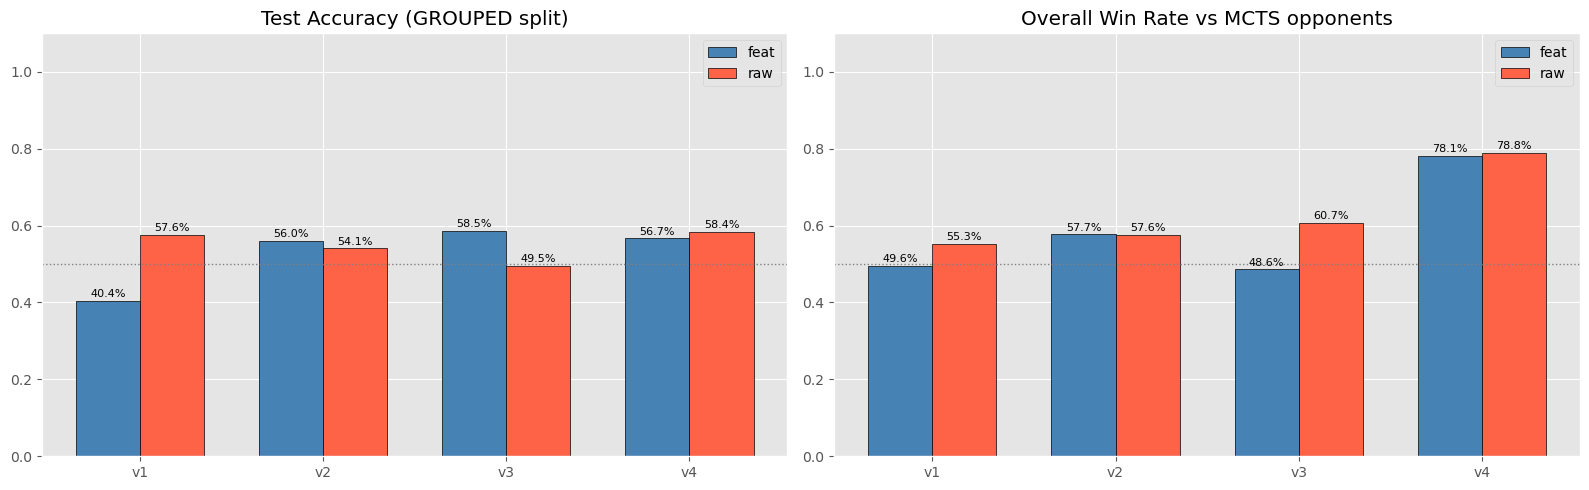

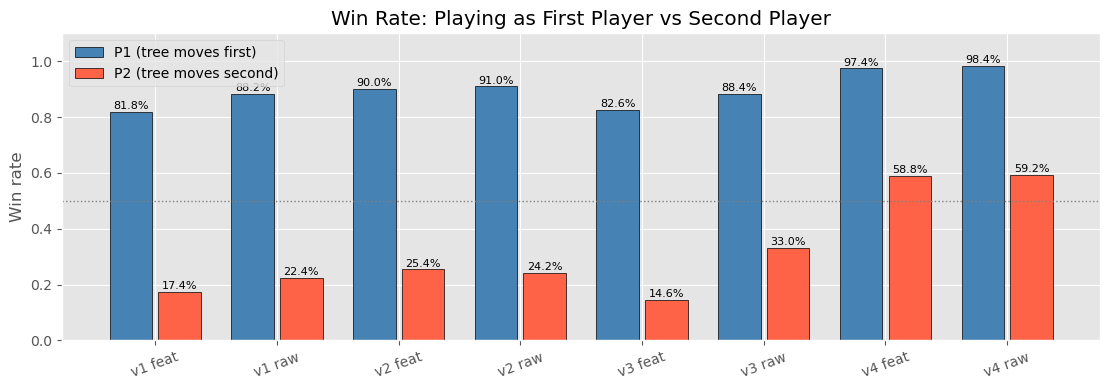

In [68]:
from matplotlib.patches import Patch

_versions = list(ALL_VERSIONS.keys())
_xi       = np.arange(len(_versions))
_w        = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in [
    (axes[0], 'Acc (GROUPED)', 'Test Accuracy (GROUPED split)'),
    (axes[1], 'Win% Overall',  'Overall Win Rate vs MCTS opponents'),
]:
    _feat_vals = [
        summary_df.loc[(summary_df['Version']==v) & (summary_df['Model']=='feat'), metric].values[0]
        for v in _versions
    ]
    _raw_vals = [
        summary_df.loc[(summary_df['Version']==v) & (summary_df['Model']=='raw'), metric].values[0]
        for v in _versions
    ]
    _feat_vals = [v if v is not None else 0 for v in _feat_vals]
    _raw_vals  = [v if v is not None else 0 for v in _raw_vals]

    ax.bar(_xi - _w/2, _feat_vals, _w, label='feat', color='steelblue', edgecolor='black')
    ax.bar(_xi + _w/2, _raw_vals,  _w, label='raw',  color='tomato',    edgecolor='black')
    for i, (fv, rv) in enumerate(zip(_feat_vals, _raw_vals)):
        if fv: ax.text(_xi[i] - _w/2, fv + 0.01, f'{fv:.1%}', ha='center', fontsize=8)
        if rv: ax.text(_xi[i] + _w/2, rv + 0.01, f'{rv:.1%}', ha='center', fontsize=8)
    ax.set_xticks(_xi)
    ax.set_xticklabels(_versions)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax.legend()

plt.tight_layout()
plt.show()

# ── P1 vs P2 plot (only versions with new-format win-rate data) ───────────────
_p1p2_rows = summary_df[summary_df['Win% P1'].notna()]
if not _p1p2_rows.empty:
    fig2, ax2 = plt.subplots(figsize=(max(8, len(_p1p2_rows) * 1.4), 4))
    _labels  = [f"{r['Version']} {r['Model']}" for _, r in _p1p2_rows.iterrows()]
    _p1_vals = _p1p2_rows['Win% P1'].values
    _p2_vals = _p1p2_rows['Win% P2'].values
    _xi2 = np.arange(len(_labels))
    ax2.bar(_xi2 - 0.2, _p1_vals, 0.35,
            label='P1 (tree moves first)',  color='steelblue', edgecolor='black')
    ax2.bar(_xi2 + 0.2, _p2_vals, 0.35,
            label='P2 (tree moves second)', color='tomato',    edgecolor='black')
    for i, (p1, p2) in enumerate(zip(_p1_vals, _p2_vals)):
        ax2.text(_xi2[i] - 0.2, p1 + 0.01, f'{p1:.1%}', ha='center', fontsize=8)
        ax2.text(_xi2[i] + 0.2, p2 + 0.01, f'{p2:.1%}', ha='center', fontsize=8)
    ax2.set_xticks(_xi2)
    ax2.set_xticklabels(_labels, rotation=20)
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel('Win rate')
    ax2.set_title('Win Rate: Playing as First Player vs Second Player')
    ax2.axhline(0.5, color='gray', linestyle=':', linewidth=1)
    ax2.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No P1/P2 data yet — delete the saved winrate_results.json files and re-run section 5 to populate.')
